# Vision Transformer (ViT) - Implemented from Scratch
## Emotion Recognition from Abstract Art
### Architecture follows Dosovitskiy et al. (2021) - "An Image is Worth 16x16 Words"

In [1]:
import torch
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

from src.dataset import get_dataloaders
from src.preprocessing import load_data, get_splits, get_class_weights
from src.model_vit import ViTClassifier
from src.train import train

In [2]:
# Device setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [ ]:
df, le = load_data("../data/dataset_final.csv")
# Full training: subset_size=15000 (run on Google Colab T4 GPU)
# For local smoke test, change to subset_size=3000
train_df, val_df, test_df = get_splits(df, subset_size=15000)
class_weights = get_class_weights(train_df, device)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 2400 | Val: 300 | Test: 300


In [4]:
# Verify Model 
model = ViTClassifier(
    image_size=224,
    patch_size=16,
    num_classes=8,
    embed_dim=256,    
    depth=4,         
    num_heads=8,    
    mlp_ratio=2,    
    dropout=0.1
).to(device)

# Test with a dummy batch
dummy = torch.randn(2, 3, 224, 224).to(device)
out = model(dummy)
print(f"Output shape: {out.shape}")  # Expected: torch.Size([2, 8])

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Output shape: torch.Size([2, 8])
Total parameters: 2,358,536


In [5]:
IMAGE_DIR = "../data/images"
train_loader, val_loader, test_loader = get_dataloaders(train_df, val_df, test_df, IMAGE_DIR)
print("DataLoaders ready")

DataLoaders ready


In [6]:
history = train(
    model, train_loader, val_loader,
    class_weights, device,
    epochs=5,
    save_path="../models/best_vit_model.pth"
)

Epoch 1/5 | Train Loss: 2.1902 | Train Acc: 0.1512 | Val Loss: 2.1193 | Val Acc: 0.1100
Epoch 2/5 | Train Loss: 2.1255 | Train Acc: 0.1192 | Val Loss: 2.1217 | Val Acc: 0.0867
Epoch 3/5 | Train Loss: 2.1042 | Train Acc: 0.1258 | Val Loss: 2.0852 | Val Acc: 0.1133
Epoch 4/5 | Train Loss: 2.1057 | Train Acc: 0.1529 | Val Loss: 2.0494 | Val Acc: 0.1067
Epoch 5/5 | Train Loss: 2.0961 | Train Acc: 0.1263 | Val Loss: 2.0728 | Val Acc: 0.2033


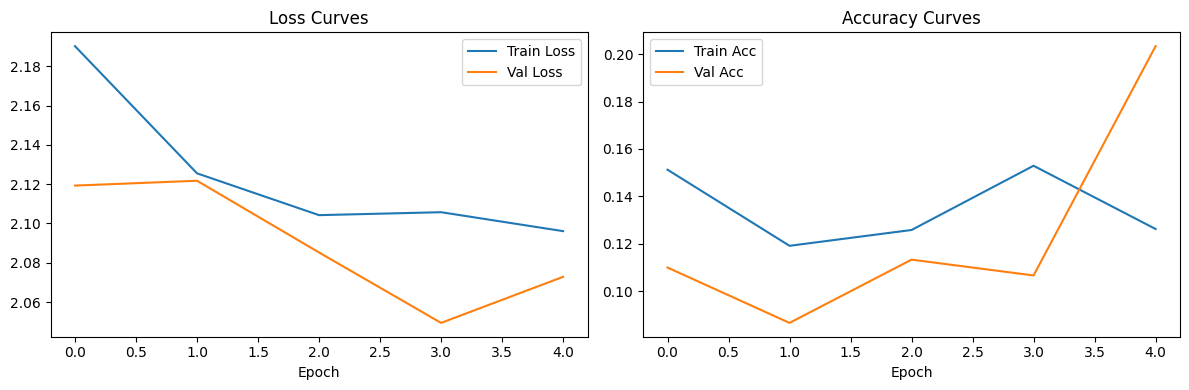

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/vit_training_curves.png")
plt.show()